# Figures — Anthropic / Eloundou

Replication and extension of key charts from the Anthropic Economic Index.

## Figure 1 · Share of Claude usage by Eloundou et al. exposure rating

Eloundou rows         : 19,265
Task penetration rows : 18,054

Claude-used tasks (penetration != 0) : 18,054

Diagnostics after merge:
  Total Claude-used tasks : 18,054
  Matched to beta      : 18,054
  Unmatched (no beta  ): 0  (0.0%)

Share of Claude-used tasks by beta bucket:
    Beta     Count     Share
  ----------------------------
     0.0     8,136     45.1%
     0.5     7,384     40.9%
     1.0     2,534     14.0%
   TOTAL    18,054    100.0%


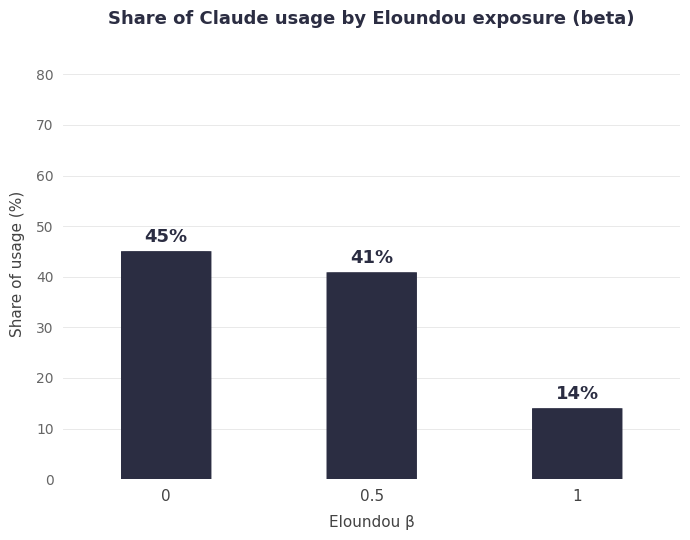


Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig1_claude_usage_beta.png


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE             = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
ELOUNDOU_PATH    = BASE / "Eloundou_Untouched" / "full_labelset.tsv"
PENETRATION_PATH = BASE / "Anthropic" / "task_penetration.csv"

# ── Switch between "beta" and "beta_new" (or any other column) here ──────────
BETA_COL = "beta"   # options: "beta", "beta_new"

OUTPUT_FIG = BASE / "Anthropic" / f"fig1_claude_usage_by_eloundou_{BETA_COL}.png"

# ── Load files ────────────────────────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_penet    = pd.read_csv(PENETRATION_PATH)

print(f"Eloundou rows         : {len(df_eloundou):,}")
print(f"Task penetration rows : {len(df_penet):,}")

# ── Identify Claude-used tasks (penetration != 0) ─────────────────────────────
df_used = df_penet[df_penet["penetration"] != 0].copy()
print(f"\nClaude-used tasks (penetration != 0) : {len(df_used):,}")

# ── Keep one beta per unique task text in the Eloundou file ───────────────────
# (some tasks appear in multiple occupations — take the first occurrence, beta is task-level)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)

# ── Normalise whitespace before merging ──────────────────────────────────────
df_used["task"] = df_used["task"].astype(str).str.strip()
df_beta["task"] = df_beta["task"].astype(str).str.strip()

# ── Merge Claude-used tasks with beta ─────────────────────────────────────────
df_merged = df_used.merge(df_beta, on="task", how="left")

n_total     = len(df_merged)
n_matched   = df_merged[BETA_COL].notna().sum()
n_unmatched = n_total - n_matched

print(f"\nDiagnostics after merge:")
print(f"  Total Claude-used tasks : {n_total:,}")
print(f"  Matched to {BETA_COL:<10}: {n_matched:,}")
print(f"  Unmatched (no {BETA_COL:<6}): {n_unmatched:,}  "
      f"({100 * n_unmatched / n_total:.1f}%)")

# ── Drop unmatched, group by beta bucket ──────────────────────────────────────
df_matched = df_merged.dropna(subset=[BETA_COL]).copy()
df_matched["beta_bucket"] = df_matched[BETA_COL].round(1)   # 0.0, 0.5, 1.0

bucket_counts = (
    df_matched.groupby("beta_bucket")
    .size()
    .reindex([0.0, 0.5, 1.0], fill_value=0)
    .rename("count")
)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).rename("pct")

print(f"\nShare of Claude-used tasks by {BETA_COL} bucket:")
print(f"  {'Beta':>6}  {'Count':>8}  {'Share':>8}")
print("  " + "-" * 28)
for b in [0.0, 0.5, 1.0]:
    print(f"  {b:>6.1f}  {int(bucket_counts[b]):>8,}  {bucket_pct[b]:>7.1f}%")
print(f"  {'TOTAL':>6}  {int(bucket_counts.sum()):>8,}  {'100.0%':>8}")

# ── Plot ──────────────────────────────────────────────────────────────────────
from pathlib import Path as _Path
REPORT_DIR = _Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG = REPORT_DIR / f"fig1_claude_usage_{BETA_COL}.png"

NAVY = "#2B2D42"
LABELS = ["0", "0.5", "1"]
X      = np.array([0.0, 0.5, 1.0])
Y      = [bucket_pct[b] for b in X]

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

bars = ax.bar(X, Y, width=0.22, color=NAVY, zorder=3,
              edgecolor="white", linewidth=0.5)

for bar_rect in bars:
    import matplotlib.patches as mpatches
    bar_rect.set_linewidth(0)
    x0 = bar_rect.get_x()
    w  = bar_rect.get_width()
    h  = bar_rect.get_height()
    fancy = mpatches.FancyBboxPatch(
        (x0, 0), w, h,
        boxstyle=mpatches.BoxStyle.Round(pad=0, rounding_size=0.02),
        facecolor=NAVY, edgecolor="none", zorder=3)
    ax.add_patch(fancy)
    bar_rect.set_visible(False)

for i, val in enumerate(Y):
    ax.text(X[i], val + 1.0, f"{val:.0f}%",
            ha="center", va="bottom",
            fontsize=13, fontweight="bold", color="#2B2D42")

ax.set_title(
    f"Share of Claude usage by Eloundou exposure ({BETA_COL})",
    fontsize=13, fontweight="bold", pad=18, color="#2B2D42"
)
ax.set_xlabel(f"Eloundou \u03b2", fontsize=11, labelpad=8, color="#444444")
ax.set_ylabel("Share of usage (%)", fontsize=11, labelpad=8, color="#444444")

ax.set_xticks(X)
ax.set_xticklabels(LABELS, fontsize=11, color="#444444")
ax.set_xlim(-0.25, 1.25)

ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=10, colors="#666666")

ax.yaxis.grid(True, color="#E5E5E5", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"\nFigure saved: {OUTPUT_FIG}")

# ── E0 tasks used by Claude (beta == 0, penetration != 0) ────────────────────
# e0_claude = df_matched[df_matched["beta"] == 0.0][["task", "penetration"]].copy()
# e0_claude = e0_claude.sort_values("penetration", ascending=False).reset_index(drop=True)
# e0_claude.index += 1

# print(f"E0 tasks used by Claude: {len(e0_claude):,}\n")
# print(e0_claude.to_string())


# Usage shares by Eloundou exposure

This notebook analyzes how observed Anthropic task usage is distributed across Eloundou exposure levels.

## Objective

The goal is to measure the share of observed task usage associated with tasks at different values of Eloundou exposure \( \beta \), using:

- Claude AI usage
- 1P API usage
- August 2025 data
- November 2025 data

The analysis is run separately for each of the four source files and then again on the pooled dataset.

## Data inputs

We use:

- `aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv`
- `aei_raw_1p_api_2025-08-04_to_2025-08-11.csv`
- `aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv`
- `aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv`

We merge these usage counts to Eloundou task exposure scores from:

- `full_labelset_new.tsv`

using the selected exposure column, here:

- `beta`

## Task-level usage extraction

The notebook first extracts task-level counts from each source file.

For **Claude AI**:

- restrict to `platform_and_product == "Claude AI (Free and Pro)"`
- restrict to `geo_id == "GLOBAL"`
- when available, use the intersection:
  - `facet == "onet_task::use_case"`
  - `variable == "onet_task_use_case_count"`
  - keep only tasks ending in `::work`
- if the use-case split is not available, fall back to:
  - `facet == "onet_task"`
  - `variable == "onet_task_count"`

For **1P API**:

- restrict to `platform_and_product == "1P API"`
- restrict to `geo_id == "GLOBAL"`
- always use:
  - `facet == "onet_task"`
  - `variable == "onet_task_count"`

After extraction:

- task names are cleaned and lowercased
- missing values are dropped
- placeholder categories such as `not_classified` and `none` are removed
- duplicate task rows are aggregated to the task level

## Merge to Eloundou exposure

Each task-level usage table is merged to the Eloundou lookup using task text.

Each matched task is assigned to one of the three exposure buckets:

- \( \beta = 0 \)
- \( \beta = 0.5 \)
- \( \beta = 1 \)

The notebook reports both:

- matched vs unmatched task counts
- matched vs unmatched usage mass

This is important because the final exposure shares depend on the quality of the task matching.

## Computation of usage shares

For each source file, we sum raw usage counts by beta bucket:

$$
\text{RawCount}(\beta=b)
=
\sum_{t:\beta_t=b} \text{count}_t
$$

We then convert these into percentage shares:

$$
\text{Share}(\beta=b)
=
\frac{\text{RawCount}(\beta=b)}
{\sum_{b' \in \{0, 0.5, 1\}} \text{RawCount}(\beta=b')}
\times 100
$$

So the reported shares tell us what fraction of observed task usage falls into each Eloundou exposure level.

## Outputs

The notebook produces two plots.

### Plot 1: separate source files

A grouped bar chart compares the beta distribution of usage across:

- Claude AI, August
- 1P API, August
- Claude AI, November
- 1P API, November

This allows a direct comparison across platform and period.

### Plot 2: pooled usage

The notebook then pools raw counts across all four files:

$$
\text{CombinedRawCount}(\beta=b)
=
\sum_{s} \text{RawCount}_s(\beta=b)
$$

and computes a single normalized share distribution from the pooled totals.

This gives the overall distribution of observed task usage by beta level across all available usage sources.

## Interpretation

This notebook is not measuring penetration directly. Instead, it measures where observed task usage is concentrated across Eloundou exposure levels.

In other words, it answers:

- how much observed usage is attached to low-exposure tasks
- how much is attached to medium-exposure tasks
- how much is attached to high-exposure tasks

This provides a descriptive bridge between:

- observed real-world LLM usage
- the theoretical task exposure framework from Eloundou

Eloundou rows              : 19,265
Unique Eloundou tasks      : 17,992
Using beta column          : beta_new
Claude use-case filter     : work
API treatment              : all task-level occurrences

Claude AI · Aug  (aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv)
  Filter used                 : Claude fallback to all use cases via onet_task + onet_task_count
  Unique tasks after filter   : 2,616
  Tasks matched to beta_new  : 2,209
  Tasks unmatched             : 408
  Matched count mass          : 728,852.00
  Unmatched count mass        : 158,099.00
    β=0.0: raw_count=157,197.00   share=21.6%
    β=0.5: raw_count=111,390.00   share=15.3%
    β=1.0: raw_count=460,265.00   share=63.1%

1P API · Aug  (aei_raw_1p_api_2025-08-04_to_2025-08-11.csv)
  Filter used                 : API all task-level occurrences via onet_task + onet_task_count
  Unique tasks after filter   : 2,054
  Tasks matched to beta_new  : 1,739
  Tasks unmatched             : 316
  Matched count mass          : 67

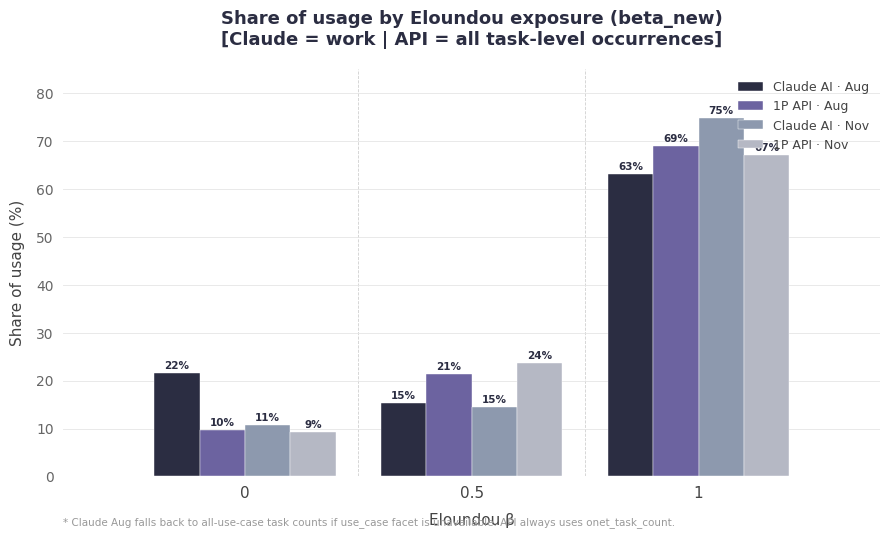

Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig_4files_beta_new_work.png



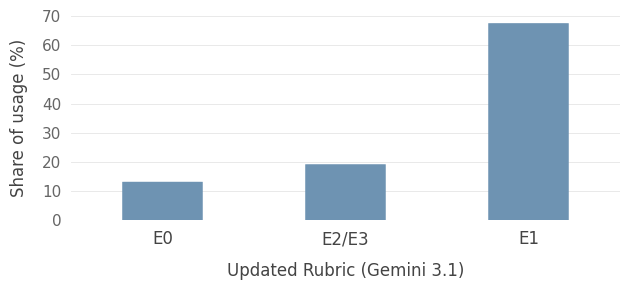


Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig_combined_beta_new_work.png


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────
BASE = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
ELOUNDOU_PATH = BASE / "Eloundou_New" / "full_labelset_new.tsv"

BETA_COL = "beta_new"
GEO_ID   = "GLOBAL"
USE_CASE = "work"   # used only for Claude AI
OUTPUT_FIG = BASE / "Anthropic" / f"fig_4files_{BETA_COL}_{USE_CASE}_corrected.png"
OUTPUT_FIG_COMBINED = BASE / "Anthropic" / f"fig_combined_{BETA_COL}_{USE_CASE}_corrected.png"

# ── Four source files ─────────────────────────────────────────────────
SOURCES = [
    {
        "label":  "Claude AI · Aug",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Aug",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "api",
    },
    {
        "label":  "Claude AI · Nov",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv",
        "period": "Nov 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Nov",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv",
        "period": "Nov 2025",
        "kind":   "api",
    },
]

# ── Eloundou beta lookup ──────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)
df_beta["task"] = df_beta["task"].astype(str).str.strip().str.lower()

print(f"Eloundou rows              : {len(df_eloundou):,}")
print(f"Unique Eloundou tasks      : {len(df_beta):,}")
print(f"Using beta column          : {BETA_COL}")
print(f"Claude use-case filter     : {USE_CASE}")
print(f"API treatment              : all task-level occurrences\n")


# ── Helper: load usage rows correctly as COUNTS ───────────────────────
def extract_task_counts(path, geo_id, source_kind, use_case):
    df = pd.read_csv(path)

    if "platform_and_product" in df.columns:
        if source_kind == "claude":
            df = df[df["platform_and_product"] == "Claude AI (Free and Pro)"].copy()
        elif source_kind == "api":
            df = df[df["platform_and_product"] == "1P API"].copy()

    if "geo_id" in df.columns:
        df = df[df["geo_id"] == geo_id].copy()

    if source_kind == "claude":
        # Prefer work-only if the intersection facet exists
        has_uc = (df["facet"] == "onet_task::use_case").any()
        if has_uc:
            out = df[
                (df["facet"] == "onet_task::use_case") &
                (df["variable"] == "onet_task_use_case_count") &
                (df["cluster_name"].astype(str).str.endswith(f"::{use_case}"))
            ].copy()

            out["task"] = out["cluster_name"].astype(str).str.rsplit("::", n=1).str[0]
            out = out.rename(columns={"value": "count"})[["task", "count"]]
            note = f"Claude filtered to use_case={use_case} via onet_task::use_case + onet_task_use_case_count"
        else:
            out = df[
                (df["facet"] == "onet_task") &
                (df["variable"] == "onet_task_count")
            ].copy()

            out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
            note = "Claude fallback to all use cases via onet_task + onet_task_count"
    else:
        # API always uses all task-level occurrences, as requested
        out = df[
            (df["facet"] == "onet_task") &
            (df["variable"] == "onet_task_count")
        ].copy()

        out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
        note = "API all task-level occurrences via onet_task + onet_task_count"

    out["task"] = out["task"].astype(str).str.strip().str.lower()
    out["count"] = pd.to_numeric(out["count"], errors="coerce")
    out = out.dropna(subset=["task", "count"]).copy()

    # Drop privacy / placeholder categories if present
    out = out[~out["task"].isin(["not_classified", "none"])].copy()

    # Aggregate in case a task appears more than once after filtering
    out = out.groupby("task", as_index=False)["count"].sum()

    return out, note


# ── Helper: merge to beta and compute beta-bucket shares ──────────────
def compute_beta_shares_from_counts(task_counts, beta_lookup, beta_col):
    df_m = task_counts.merge(beta_lookup, on="task", how="left")

    matched_tasks = df_m[beta_col].notna().sum()
    unmatched_tasks = df_m[beta_col].isna().sum()
    matched_count_mass = df_m.loc[df_m[beta_col].notna(), "count"].sum()
    unmatched_count_mass = df_m.loc[df_m[beta_col].isna(), "count"].sum()

    df_m = df_m.dropna(subset=[beta_col]).copy()
    df_m["beta_bucket"] = pd.to_numeric(df_m[beta_col], errors="coerce").round(1)
    df_m = df_m[df_m["beta_bucket"].isin([0.0, 0.5, 1.0])].copy()

    raw_counts = (
        df_m.groupby("beta_bucket")["count"]
        .sum()
        .reindex([0.0, 0.5, 1.0], fill_value=0.0)
    )

    share = raw_counts / raw_counts.sum() * 100 if raw_counts.sum() > 0 else raw_counts.copy()

    diagnostics = {
        "tasks_total": len(task_counts),
        "tasks_matched": int(matched_tasks),
        "tasks_unmatched": int(unmatched_tasks),
        "count_mass_matched": float(matched_count_mass),
        "count_mass_unmatched": float(unmatched_count_mass),
        "raw_counts": raw_counts,
        "share": share,
    }
    return diagnostics


# ── Compute for all four files ────────────────────────────────────────
for src in SOURCES:
    print(f"{src['label']}  ({src['path'].name})")
    task_counts, note = extract_task_counts(src["path"], GEO_ID, src["kind"], USE_CASE)
    diag = compute_beta_shares_from_counts(task_counts, df_beta, BETA_COL)

    src["note"] = note
    src["task_counts"] = task_counts
    src["diag"] = diag
    src["share"] = diag["share"]
    src["raw_counts"] = diag["raw_counts"]

    print(f"  Filter used                 : {note}")
    print(f"  Unique tasks after filter   : {diag['tasks_total']:,}")
    print(f"  Tasks matched to {BETA_COL:<10}: {diag['tasks_matched']:,}")
    print(f"  Tasks unmatched             : {diag['tasks_unmatched']:,}")
    print(f"  Matched count mass          : {diag['count_mass_matched']:,.2f}")
    print(f"  Unmatched count mass        : {diag['count_mass_unmatched']:,.2f}")
    for b in [0.0, 0.5, 1.0]:
        print(
            f"    β={b:.1f}: raw_count={diag['raw_counts'][b]:,.2f}   share={diag['share'][b]:.1f}%"
        )
    print()


# ── Paths & palette ────────────────────────────────────────────────────
from pathlib import Path as _Path
import matplotlib.patches as mpatches

REPORT_DIR = _Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG          = REPORT_DIR / f"fig_4files_{BETA_COL}_{USE_CASE}.png"
OUTPUT_FIG_COMBINED = REPORT_DIR / f"fig_combined_{BETA_COL}_{USE_CASE}.png"

PALETTE_4 = ["#2B2D42", "#6C63A0", "#8D99AE", "#B5B8C4"]

X = np.array([0.0, 0.5, 1.0])
n = len(SOURCES)
width = 0.10
offsets = np.linspace(-(n - 1) * width / 2, (n - 1) * width / 2, n)

# ── Plot 1: four files side by side ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

for i, src in enumerate(SOURCES):
    bars = ax.bar(
        X + offsets[i], src["share"].values, width=width,
        color=PALETTE_4[i], label=src["label"], zorder=3,
        edgecolor="white", linewidth=0.3,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f"{h:.0f}%", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold", color="#2B2D42")

for xv in [0.25, 0.75]:
    ax.axvline(xv, color="#D0D0D0", linewidth=0.6, linestyle="--", zorder=0)

ax.set_title(
    f"Share of usage by Eloundou exposure ({BETA_COL})\n"
    f"[Claude = {USE_CASE} | API = all task-level occurrences]",
    fontsize=13, fontweight="bold", pad=18, color="#2B2D42",
)
ax.set_xlabel("Eloundou \u03b2", fontsize=11, labelpad=8, color="#444444")
ax.set_ylabel("Share of usage (%)", fontsize=11, labelpad=8, color="#444444")

ax.set_xticks(X)
ax.set_xticklabels(["0", "0.5", "1"], fontsize=11, color="#444444")
ax.set_xlim(-0.4, 1.4)
ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=10, colors="#666666")

ax.yaxis.grid(True, color="#E5E5E5", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

ax.legend(fontsize=9, loc="upper right", frameon=False, labelcolor="#444444")

ax.annotate(
    "* Claude Aug falls back to all-use-case task counts if use_case facet is unavailable. "
    "API always uses onet_task_count.",
    xy=(0, -0.1), xycoords="axes fraction", fontsize=7.5, color="#999999", va="top"
)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure saved: {OUTPUT_FIG}\n")


# ── Plot 2: pooled across all four sources ────────────────────────────
combined_raw = pd.Series([0.0, 0.0, 0.0], index=[0.0, 0.5, 1.0])

for src in SOURCES:
    combined_raw = combined_raw.add(src["raw_counts"], fill_value=0)

combined_share = combined_raw / combined_raw.sum() * 100 if combined_raw.sum() > 0 else combined_raw.copy()

# colorway matched to the reference image
BAR_COLOR = "#6E93B2"
GRID_COLOR = "#E5E5E5"
TEXT_COLOR = "#444444"
TICK_COLOR = "#666666"

fig, ax = plt.subplots(figsize=(6.4, 3))   # square
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

Y_comb = combined_share.values
bars = ax.bar(
    X, Y_comb, width=0.22,
    color=BAR_COLOR, zorder=3,
    edgecolor="none", linewidth=0
)

for bar_rect in bars:
    x0 = bar_rect.get_x()
    w = bar_rect.get_width()
    h = bar_rect.get_height()
    fancy = mpatches.FancyBboxPatch(
        (x0, 0), w, h,
        boxstyle=mpatches.BoxStyle.Round(pad=0, rounding_size=0.02),
        facecolor=BAR_COLOR, edgecolor="none", zorder=3
    )
    ax.add_patch(fancy)
    bar_rect.set_visible(False)

# keep x and y, but rename x-axis label
ax.set_xlabel("Updated Rubric (Gemini 3.1)", fontsize=12, labelpad=10, color=TEXT_COLOR)
ax.set_ylabel("Share of usage (%)", fontsize=12, labelpad=10, color=TEXT_COLOR)

ax.set_xticks(X)
ax.set_xticklabels(["E0", "E2/E3", "E1"], fontsize=12, color=TEXT_COLOR)
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(0, 70)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=11, colors=TICK_COLOR)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

# no title, no annotations, no value labels

plt.tight_layout()
plt.savefig(OUTPUT_FIG_COMBINED, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"\nFigure saved: {OUTPUT_FIG_COMBINED}")

## Radar Chart · Theoretical vs. Observed Exposure by SOC Major Group

Each spoke of the radar corresponds to a **SOC major group** (2-digit level, e.g. Management, Computer & Math, …).

| Series | Metric | Description |
|--------|--------|-------------|
| Blue | `time_based_score` | Theoretical exposure — pi-weighted average of `beta_new` |
| Red | `observed_penetration_score` | Observed exposure — pi-weighted average of `penetration_beta_new` |

Both series are aggregated to the major-group level using **employee-weighted averages** (employee counts from `sp500_company_data.parquet`).

SP500 weighted employee records: 26,493,389
Unique occupations in SP500:     1,007
Occupations matched:             917 / 923
Weighted employees matched:      24,323,989 (91.8%)

SOC groups in radar: 22
soc2                      label  theoretical  observed n_employees
  11                 Management     0.536228  0.166754   4,545,547
  13         Business & finance     0.697001  0.232281   2,379,876
  15            Computer & math     0.743747  0.321845   5,453,983
  17 Architecture & engineering     0.566079  0.072889   1,374,124
  19     Life & social sciences     0.499277  0.113467     452,211
  21            Social services     0.384524  0.036451     114,507
  23                      Legal     0.414399  0.126730     259,173
  25        Education & library     0.305276  0.110661     139,395
  27               Arts & media     0.525611  0.215423     773,996
  29   Healthcare practitioners     0.310791  0.066892     675,575
  31         Healthcare support     0.139207  0.028853     1

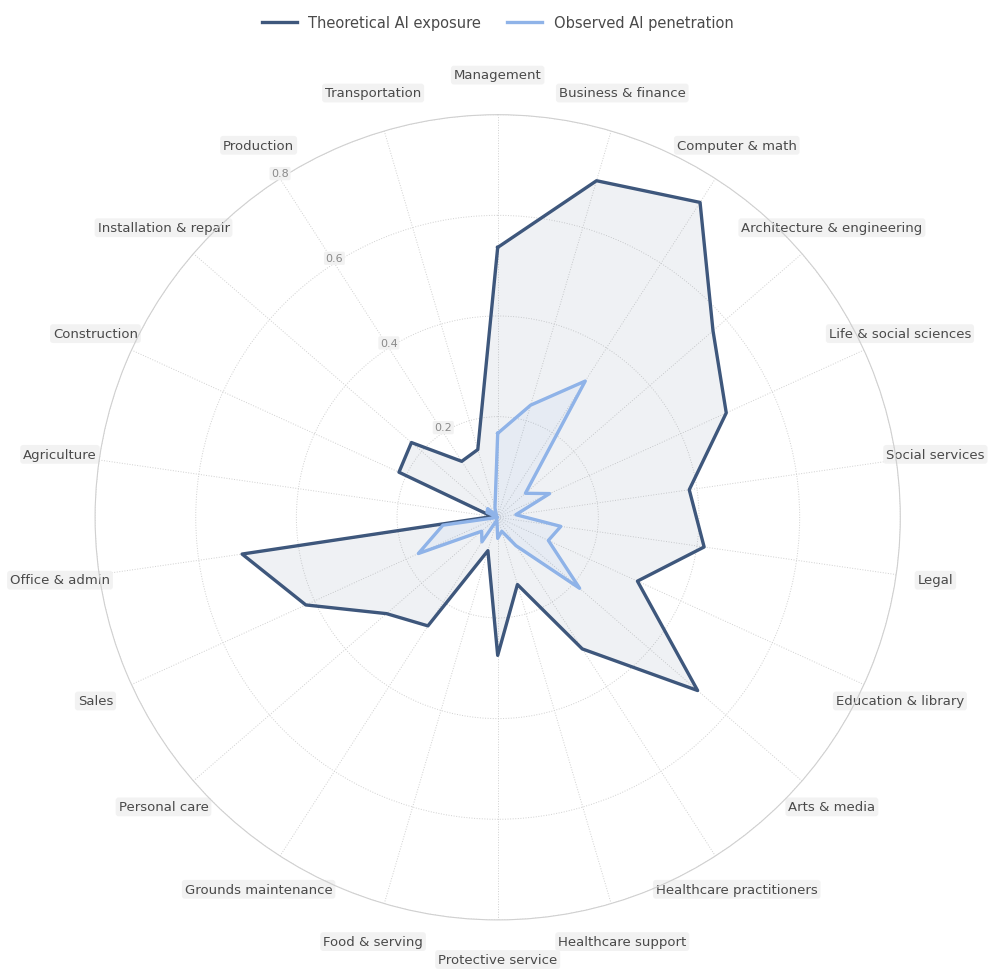


Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/radar_theoretical_vs_observed.png
Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/radar_theoretical_vs_observed_nobg.png


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from pathlib import Path
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────
BASE        = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
OCC_FILE    = BASE / "Eloundou_New" / "occ_level_new.csv"
SP500_FILE  = BASE / "data" / "sp500_company_data.parquet"
REPORT_DIR  = BASE / "Report images"
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG  = REPORT_DIR / "radar_theoretical_vs_observed.png"
OUTPUT_FIG_NOBG = REPORT_DIR / "radar_theoretical_vs_observed_nobg.png"

# ── SOC major-group labels ────────────────────────────────────────────
SOC_LABELS = {
    "11": "Management",
    "13": "Business & finance",
    "15": "Computer & math",
    "17": "Architecture & engineering",
    "19": "Life & social sciences",
    "21": "Social services",
    "23": "Legal",
    "25": "Education & library",
    "27": "Arts & media",
    "29": "Healthcare practitioners",
    "31": "Healthcare support",
    "33": "Protective service",
    "35": "Food & serving",
    "37": "Grounds maintenance",
    "39": "Personal care",
    "41": "Sales",
    "43": "Office & admin",
    "45": "Agriculture",
    "47": "Construction",
    "49": "Installation & repair",
    "51": "Production",
    "53": "Transportation",
}

# ── 1. Load occ-level scores ──────────────────────────────────────────
df_occ = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ.columns = df_occ.columns.str.strip()
df_occ["O*NET-SOC Code"] = df_occ["O*NET-SOC Code"].astype(str).str.strip()
df_occ["soc2"] = df_occ["O*NET-SOC Code"].str[:2]

# ── 2. Load weighted employee counts ──────────────────────────────────
_emp_df = pq.read_table(SP500_FILE, columns=["onet_code", "weight"]).to_pandas()
_emp_df["onet_code"] = _emp_df["onet_code"].astype(str).str.strip()
_emp_df["weight"] = _emp_df["weight"].fillna(1.0)
_emp_df = _emp_df[_emp_df["onet_code"].str.match(r"^\d{2}-")]

w_total_sp500 = _emp_df["weight"].sum()
emp_counts = (
    _emp_df.groupby("onet_code")["weight"]
    .sum()
    .rename("n_employees")
    .rename_axis("O*NET-SOC Code")
    .reset_index()
)

print(f"SP500 weighted employee records: {w_total_sp500:,.0f}")
print(f"Unique occupations in SP500:     {len(emp_counts):,}")

# ── 3. Merge weighted counts onto occ scores ─────────────────────────
n_occ_before = len(df_occ)
df = df_occ.merge(emp_counts, on="O*NET-SOC Code", how="inner")
w_matched = df["n_employees"].sum()

print(f"Occupations matched:             {len(df):,} / {n_occ_before}")
print(f"Weighted employees matched:      {w_matched:,.0f} ({100*w_matched/w_total_sp500:.1f}%)")

# ── 4. Employee-weighted aggregation to SOC major group ──────────────
def wavg(group, col):
    mask = group[col].notna() & (group["n_employees"] > 0)
    w = group.loc[mask, "n_employees"]
    v = group.loc[mask, col]
    return (v * w).sum() / w.sum() if w.sum() > 0 else np.nan

records = []
for soc2, grp in df.groupby("soc2"):
    records.append({
        "soc2":        soc2,
        "label":       SOC_LABELS.get(soc2, soc2),
        "theoretical": wavg(grp, "time_based_score"),
        "observed":    wavg(grp, "observed_penetration_score"),
        "n_employees": grp["n_employees"].sum(),
    })

df_radar = pd.DataFrame(records).sort_values("soc2").reset_index(drop=True)

print(f"\nSOC groups in radar: {len(df_radar)}")
_disp_r = df_radar[["soc2", "label", "theoretical", "observed", "n_employees"]].copy()
_disp_r["n_employees"] = _disp_r["n_employees"].apply(lambda x: f"{x:,.0f}")
print(_disp_r.to_string(index=False))

# ── 5. Build radar chart ──────────────────────────────────────────────
categories = df_radar["label"].tolist()
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

vals_theoretical = df_radar["theoretical"].fillna(0).tolist()
vals_observed    = df_radar["observed"].fillna(0).tolist()
vals_theoretical += vals_theoretical[:1]
vals_observed    += vals_observed[:1]

DARK_BLUE  = "#3E577C"
LIGHT_BLUE = "#8FB3E8"
GRID_COLOR = "#D0D0D0"
TEXT_COLOR = "#4A4A4A"

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# solid data series
ax.plot(
    angles, vals_theoretical,
    color=DARK_BLUE, linewidth=2.4, linestyle="-",
    zorder=4
)
ax.fill(angles, vals_theoretical, color=DARK_BLUE, alpha=0.08, zorder=2)

ax.plot(
    angles, vals_observed,
    color=LIGHT_BLUE, linewidth=2.4, linestyle="-",
    zorder=4
)
ax.fill(angles, vals_observed, color=LIGHT_BLUE, alpha=0.10, zorder=2)

ax.set_ylim(0, 0.8)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels([])

# dotted gray grid only
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, linestyle=":", zorder=0)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7, linestyle=":", zorder=0)
ax.spines["polar"].set_color(GRID_COLOR)
ax.spines["polar"].set_linewidth(0.8)

# scale labels near Production
prod_idx = categories.index("Production")
prod_angle = angles[prod_idx]
for tick_val in [0.2, 0.4, 0.6, 0.8]:
    ax.text(
        prod_angle, tick_val, f"{tick_val:.1f}",
        fontsize=8, color="#8A8A8A",
        ha="center", va="bottom", zorder=6,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="#F2F2F2", edgecolor="none", alpha=0.95)
    )

# category labels with gray text boxes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9.5, color=TEXT_COLOR, fontweight="normal")
ax.tick_params(axis="x", pad=18)

for lbl in ax.get_xticklabels():
    lbl.set_zorder(6)
    lbl.set_bbox(dict(
        boxstyle="round,pad=0.22",
        facecolor="#F2F2F2",
        edgecolor="none",
        alpha=0.95
    ))

legend_handles = [
    Line2D([0], [0], color=DARK_BLUE, linewidth=2.4, linestyle="-",
           label="Theoretical AI exposure"),
    Line2D([0], [0], color=LIGHT_BLUE, linewidth=2.4, linestyle="-",
           label="Observed AI penetration"),
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncol=2,
    fontsize=10.5,
    frameon=False,
    labelcolor=TEXT_COLOR,
    handlelength=2.4,
    columnspacing=1.8
)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight", transparent=True)
plt.savefig(OUTPUT_FIG_NOBG, dpi=200, bbox_inches="tight", transparent=True)
plt.show()

print(f"\nFigure saved: {OUTPUT_FIG}")
print(f"Figure saved: {OUTPUT_FIG_NOBG}")

## Scatter Plots · AI Exposure vs. BLS Projected Employment Change

Two panels per figure — **left: OLS (unweighted)**, **right: WLS (employee-weighted)**.

| Figure | X-axis metric |
|--------|---------------|
| Figure A | `time_based_score` (theoretical, pi-weighted β) |
| Figure B | `observed_penetration_score` (observed penetration) |

SP500 weighted employees total:  26,493,389
Matched to occ scores (soc6):    24,323,989 (91.8%)
Occupations after BLS merge:     768 / 798
Weighted empl. after BLS merge:  24,116,441 (91.0%)


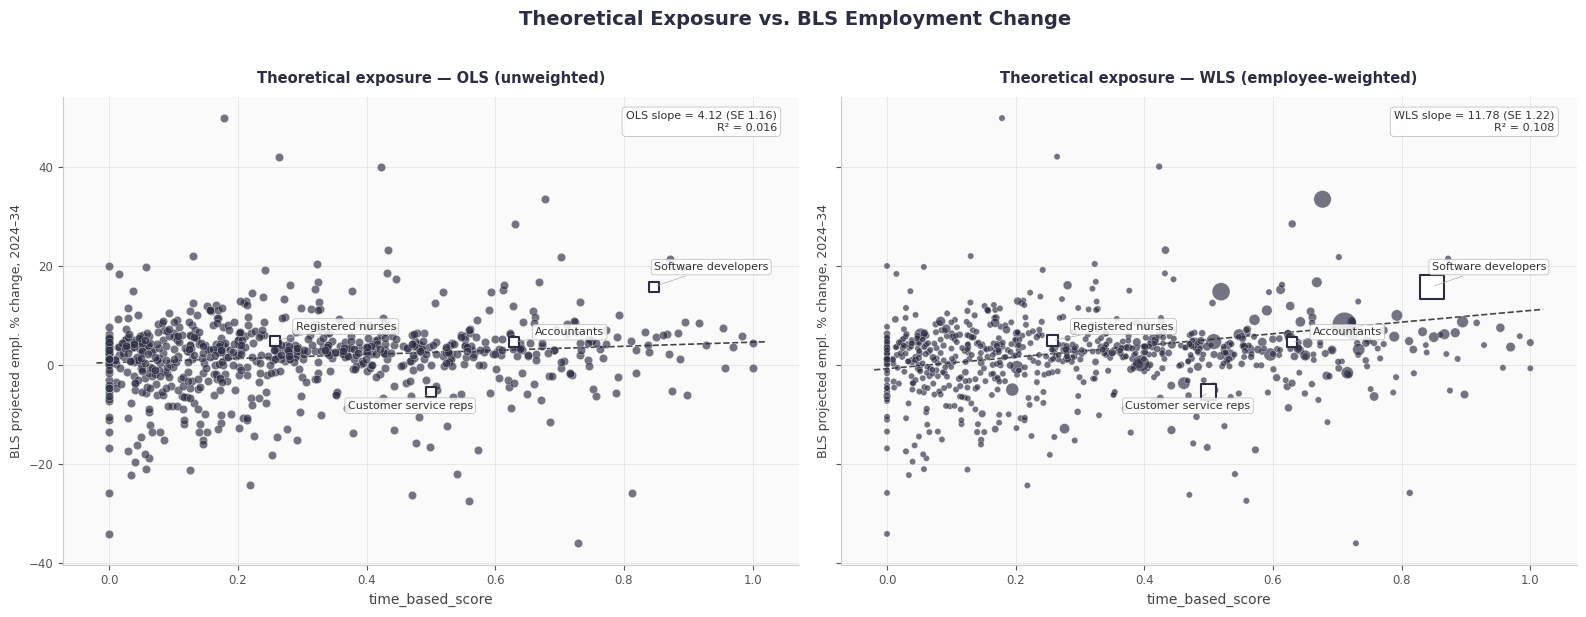

Figure A saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_theoretical_panel.png  (n = 768, 768)


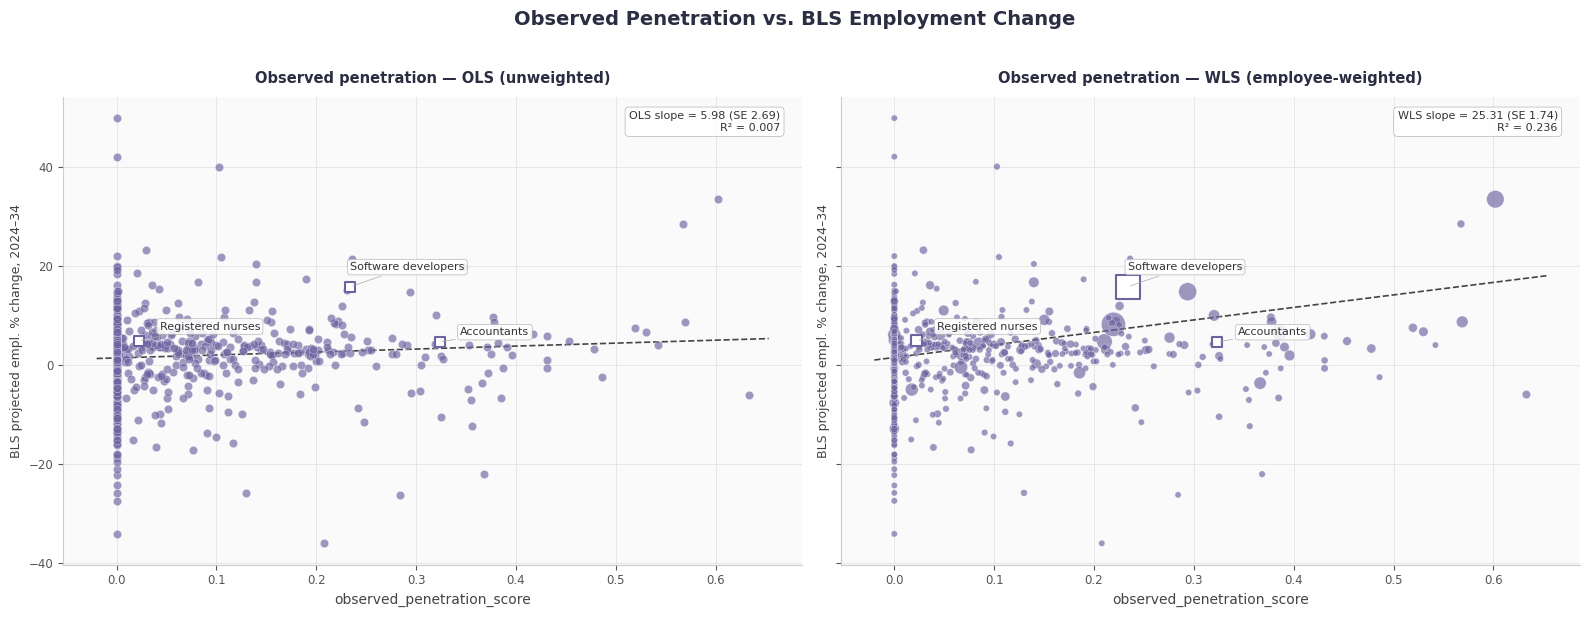

Figure B saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_observed_panel.png  (n = 688, 688)


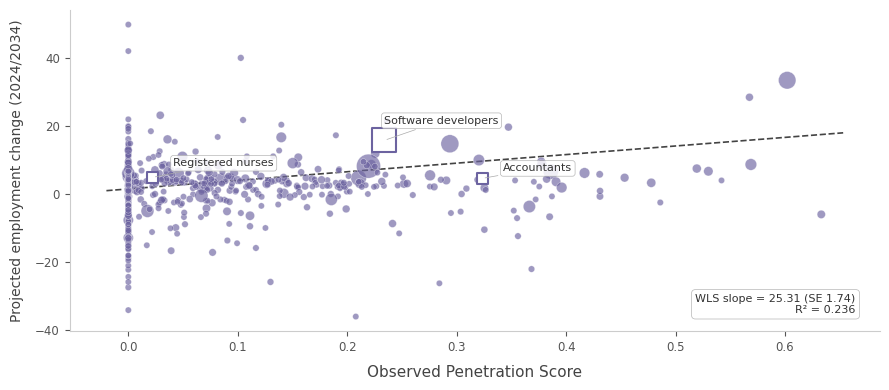

Solo figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_observed_wls_solo.png


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import statsmodels.api as sm
from scipy import stats as sp_stats
from pathlib import Path

BASE       = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
OCC_FILE   = BASE / "Eloundou_New" / "occ_level_new.csv"
BLS_FILE   = BASE / "data" / "Employment Projections.csv"
SP500_FILE = BASE / "data" / "sp500_company_data.parquet"

# ── 1. Load occ-level scores + weighted emp counts at detailed level ──
df_occ = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ.columns = df_occ.columns.str.strip()
df_occ["O*NET-SOC Code"] = df_occ["O*NET-SOC Code"].astype(str).str.strip()
df_occ["soc6"] = df_occ["O*NET-SOC Code"].str[:7]

# Weighted employee counts per detailed O*NET code
_emp_sc = pq.read_table(SP500_FILE, columns=["onet_code", "weight"]).to_pandas()
_emp_sc["onet_code"] = _emp_sc["onet_code"].astype(str).str.strip()
_emp_sc["weight"] = _emp_sc["weight"].fillna(1.0)
_emp_sc = _emp_sc[_emp_sc["onet_code"].str.match(r"^\d{2}-")]
w_total_sp500 = _emp_sc["weight"].sum()

emp_detail = (
    _emp_sc.groupby("onet_code")["weight"]
    .sum().rename("n_emp_detail")
    .reset_index().rename(columns={"onet_code": "O*NET-SOC Code"})
)

# Merge weighted counts onto detailed occ scores
df_occ = df_occ.merge(emp_detail, on="O*NET-SOC Code", how="left")
df_occ["n_emp_detail"] = df_occ["n_emp_detail"].fillna(0)

# Aggregate to soc6 using employee-weighted averages
def _wavg_soc6(grp, col):
    mask = grp[col].notna() & (grp["n_emp_detail"] > 0)
    w = grp.loc[mask, "n_emp_detail"]
    v = grp.loc[mask, col]
    return (v * w).sum() / w.sum() if w.sum() > 0 else np.nan

soc6_records = []
for soc6, grp in df_occ.groupby("soc6"):
    soc6_records.append({
        "soc6": soc6,
        "time_based_score":            _wavg_soc6(grp, "time_based_score"),
        "observed_penetration_score":  _wavg_soc6(grp, "observed_penetration_score"),
        "dv_rating_new":               _wavg_soc6(grp, "dv_rating_new"),
        "n_employees":                 grp["n_emp_detail"].sum(),
        "Title":                       grp["Title"].dropna().iloc[0] if grp["Title"].notna().any() else soc6,
    })

occ_agg = pd.DataFrame(soc6_records)
occ_agg["exposure_theo"] = occ_agg["time_based_score"].fillna(occ_agg["dv_rating_new"])
occ_agg["exposure_obs"]  = occ_agg["observed_penetration_score"]
occ_agg["Title"] = occ_agg["Title"].astype(str).str.strip()

w_in_occ_agg = occ_agg["n_employees"].sum()
print(f"SP500 weighted employees total:  {w_total_sp500:,.0f}")
print(f"Matched to occ scores (soc6):    {w_in_occ_agg:,.0f} ({100*w_in_occ_agg/w_total_sp500:.1f}%)")

# ── 2. Load BLS Employment Projections ─────────────────────────────────
df_bls = pd.read_csv(BLS_FILE)
df_bls["soc6"] = (
    df_bls["Occupation Code"].astype(str)
    .str.replace("=", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.strip()
)
df_bls["pct_change"] = pd.to_numeric(
    df_bls["Employment Percent Change, 2024-2034"], errors="coerce"
)

# ── 3. Merge occ scores + BLS (n_employees already in occ_agg) ────────
n_before_bls = len(occ_agg)
df_all = occ_agg.merge(df_bls[["soc6", "pct_change"]], on="soc6", how="inner")
# Keep only occupations with SP500 employees
df_all = df_all[df_all["n_employees"] > 0].copy()

w_after_bls = df_all["n_employees"].sum()
print(f"Occupations after BLS merge:     {len(df_all)} / {n_before_bls}")
print(f"Weighted empl. after BLS merge:  {w_after_bls:,.0f} ({100*w_after_bls/w_total_sp500:.1f}%)")
assert len(df_all) <= n_before_bls, "BLS merge should not duplicate rows"

LABELS = {
    "15-1252": "Software developers",
    "29-1141": "Registered nurses",
    "13-2011": "Accountants",
    "43-4051": "Customer service reps",
}
OFFSETS = {
    "15-1252": (0, 12),
    "29-1141": (15, 8),
    "13-2011": (15, 5),
    "43-4051": (-60, -12),
}

NAVY   = "#2B2D42"
PURPLE = "#6C63A0"

REPORT_DIR = BASE / "Report images"
REPORT_DIR.mkdir(exist_ok=True)

# ── Helper: draw one panel ─────────────────────────────────────────────
def draw_panel(ax, data, xcol, color, title, weighted):
    d = data.dropna(subset=[xcol, "pct_change"]).copy()

    if weighted:
        X = sm.add_constant(d[xcol])
        fit = sm.WLS(d["pct_change"], X, weights=d["n_employees"]).fit()
        sl, ic, se, rsq = fit.params.iloc[1], fit.params.iloc[0], fit.bse.iloc[1], fit.rsquared
        reg_label = "WLS"
    else:
        sl, ic, r_val, _, se = sp_stats.linregress(d[xcol], d["pct_change"])
        rsq = r_val ** 2
        reg_label = "OLS"

    if weighted:
        n_min, n_max = d["n_employees"].min(), d["n_employees"].max()
        sz = 20 + 280 * (d["n_employees"] - n_min) / max(n_max - n_min, 1)
    else:
        sz = 36

    labeled_mask = d["soc6"].isin(LABELS)

    ax.scatter(d.loc[~labeled_mask, xcol], d.loc[~labeled_mask, "pct_change"],
               s=sz if isinstance(sz, int) else sz[~labeled_mask],
               color=color, edgecolors="white", linewidths=0.3,
               alpha=0.65, zorder=3)
    ax.scatter(d.loc[labeled_mask, xcol], d.loc[labeled_mask, "pct_change"],
               s=60 if not weighted else sz[labeled_mask],
               facecolors="white", edgecolors=color, linewidths=1.5,
               marker="s", zorder=4)

    x_line = np.linspace(d[xcol].min() - 0.02, d[xcol].max() + 0.02, 200)
    ax.plot(x_line, sl * x_line + ic, color="#444444", lw=1.2, ls="--", zorder=2)

    for _, row in d[labeled_mask].iterrows():
        soc = row["soc6"]
        ox, oy = OFFSETS.get(soc, (10, 8))
        ax.annotate(
            LABELS[soc], xy=(row[xcol], row["pct_change"]),
            xytext=(ox, oy), textcoords="offset points", fontsize=8,
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#AAAAAA",
                      lw=0.5, alpha=0.85),
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.5), zorder=5)

    ax.text(0.97, 0.97,
            f"{reg_label} slope = {sl:.2f} (SE {se:.2f})\nR\u00b2 = {rsq:.3f}",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#AAAAAA",
                      lw=0.5, alpha=0.85))

    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=10, color="#2B2D42")
    ax.set_ylabel("BLS projected empl. % change, 2024\u201334", fontsize=9, color="#444444")
    ax.tick_params(axis="both", labelsize=8.5, colors="#555555")
    ax.yaxis.grid(True, color="#E0E0E0", lw=0.5, zorder=0)
    ax.xaxis.grid(True, color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

    return len(d), sl, se, rsq

# ═══════════════════════════════════════════════════════════════════════
# Figure A · time_based_score  (OLS | WLS)
# ═══════════════════════════════════════════════════════════════════════
fig_a, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig_a.patch.set_alpha(0)
for a in (ax_a1, ax_a2):
    a.set_facecolor("#FAFAFA")

n1, *_ = draw_panel(ax_a1, df_all, "exposure_theo", NAVY,
                     "Theoretical exposure — OLS (unweighted)", weighted=False)
ax_a1.set_xlabel("time_based_score", fontsize=10, color="#444444")

n2, *_ = draw_panel(ax_a2, df_all, "exposure_theo", NAVY,
                     "Theoretical exposure — WLS (employee-weighted)", weighted=True)
ax_a2.set_xlabel("time_based_score", fontsize=10, color="#444444")

fig_a.suptitle("Theoretical Exposure vs. BLS Employment Change",
               fontsize=14, fontweight="bold", y=1.02, color="#2B2D42")
fig_a.tight_layout()
out_a = REPORT_DIR / "scatter_theoretical_panel.png"
fig_a.savefig(out_a, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure A saved: {out_a}  (n = {n1}, {n2})")

# ═══════════════════════════════════════════════════════════════════════
# Figure B · observed_penetration_score  (OLS | WLS)
# ═══════════════════════════════════════════════════════════════════════
fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig_b.patch.set_alpha(0)
for a in (ax_b1, ax_b2):
    a.set_facecolor("#FAFAFA")

n3, *_ = draw_panel(ax_b1, df_all, "exposure_obs", PURPLE,
                     "Observed penetration — OLS (unweighted)", weighted=False)
ax_b1.set_xlabel("observed_penetration_score", fontsize=10, color="#444444")

n4, *_ = draw_panel(ax_b2, df_all, "exposure_obs", PURPLE,
                     "Observed penetration — WLS (employee-weighted)", weighted=True)
ax_b2.set_xlabel("observed_penetration_score", fontsize=10, color="#444444")

fig_b.suptitle("Observed Penetration vs. BLS Employment Change",
               fontsize=14, fontweight="bold", y=1.02, color="#2B2D42")
fig_b.tight_layout()
out_b = REPORT_DIR / "scatter_observed_panel.png"
fig_b.savefig(out_b, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure B saved: {out_b}  (n = {n3}, {n4})")

# ── Solo: WLS observed penetration panel ─────────────────────────────
fig_solo, ax_solo = plt.subplots(figsize=(9, 4))
fig_solo.patch.set_alpha(0)
ax_solo.set_facecolor("none")

draw_panel(ax_solo, df_all, "exposure_obs", PURPLE,
           "", weighted=True)

ax_solo.set_title("")
ax_solo.set_xlabel("Observed Penetration Score", fontsize=11,
                   color="#444444", labelpad=8)
ax_solo.set_ylabel("Projected employment change (2024/2034)",
                   fontsize=10, color="#444444", labelpad=8)

# Remove grid, move stat box to bottom-right
ax_solo.yaxis.grid(False)
ax_solo.xaxis.grid(False)
for txt in ax_solo.texts:
    if "slope" in txt.get_text().lower() or "r²" in txt.get_text().lower():
        txt.set_position((0.97, 0.05))
        txt.set_verticalalignment("bottom")

fig_solo.tight_layout()
out_solo = REPORT_DIR / "scatter_observed_wls_solo.png"
fig_solo.savefig(out_solo, dpi=200, bbox_inches="tight",
                 transparent=True, facecolor="none")
plt.show()
print(f"Solo figure saved: {out_solo}")